In [1]:
# Import thư viện cần thiết
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dữ liệu train và test
train_path = '../../../data/raw/train.csv'
test_path = '../../../data/raw/test.csv'

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

In [3]:
train_data = train_data.drop(train_data[(train_data['GrLivArea'] > 4000) & (train_data['SalePrice'] < 300000)].index)
train_data["SalePrice"] = np.log1p(train_data["SalePrice"])
train_data["TotalSF"] = train_data["TotalBsmtSF"] + train_data["1stFlrSF"] + train_data["2ndFlrSF"]
test_data["TotalSF"] = test_data["TotalBsmtSF"] + test_data["1stFlrSF"] + test_data["2ndFlrSF"]

train_data["HouseAge"] = train_data["YrSold"] - train_data["YearBuilt"]
test_data["HouseAge"] = test_data["YrSold"] - test_data["YearBuilt"]

train_data["QualCond"] = train_data["OverallQual"]*train_data["OverallCond"]
test_data["QualCond"] = test_data["OverallQual"]*test_data["OverallCond"]

In [4]:
target = "SalePrice"
numerical_features = train_data.select_dtypes(include=['float64', 'int64']).columns
categorical_features = train_data.select_dtypes(include='object').columns
num_features = [col for col in numerical_features if col != target]

# Fill missing
train_data[categorical_features] = train_data[categorical_features].fillna("Missing")
test_data[categorical_features] = test_data[categorical_features].fillna("Missing")
train_data[num_features] = train_data[num_features].fillna(0)
test_data[num_features] = test_data[num_features].fillna(0)

# Đồng nhất categories giữa train và test
for col in categorical_features:
    all_values = pd.concat([train_data[col], test_data[col]], axis=0).astype(str).unique()
    train_data[col] = pd.Categorical(train_data[col].astype(str), categories=all_values)
    test_data[col] = pd.Categorical(test_data[col].astype(str), categories=all_values)

In [6]:
train = train_data.copy()
test = test_data.copy()

Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 356, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 454, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1595, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1588, in _read


🚀 Start run: LightGBM_regression_best_120118
🔍 Đang tìm tham số tốt nhất cho LightGBM bằng Optuna (20 lần thử)...


Best trial: 0. Best value: -0.0164565:   5%|▌         | 1/20 [00:07<02:25,  7.66s/it]

[I 2025-10-28 12:01:26,028] Trial 0 finished with value: -0.016456459221600373 and parameters: {'n_estimators': 1266, 'learning_rate': 0.05917598010073278, 'max_depth': 6, 'num_leaves': 123, 'subsample': 0.7674483785639926, 'colsample_bytree': 0.5519107801182895, 'lambda_l1': 0.0004673477090755377, 'lambda_l2': 0.5768180337653064, 'min_child_samples': 20}. Best is trial 0 with value: -0.016456459221600373.


Best trial: 0. Best value: -0.0164565:  10%|█         | 2/20 [00:14<02:13,  7.40s/it]

...

[I 2025-10-28 12:02:08,586] Trial 17 finished with value: -0.017132930102108663 and parameters: {'n_estimators': 1716, 'learning_rate': 0.0590398584572359, 'max_depth': 7, 'num_leaves': 178, 'subsample': 0.7494674909424954, 'colsample_bytree': 0.613699639296284, 'lambda_l1': 0.004328511268245518, 'lambda_l2': 0.26614748941469124, 'min_child_samples': 42}. Best is trial 9 with value: -0.01585251905699248.


Best trial: 9. Best value: -0.0158525:  95%|█████████▌| 19/20 [00:51<00:01,  1.88s/it]

[I 2025-10-28 12:02:09,543] Trial 18 finished with value: -0.01866896356169809 and parameters: {'n_estimators': 1027, 'learning_rate': 0.10272030464779375, 'max_depth': 5, 'num_leaves': 145, 'subsample': 0.6183018977884392, 'colsample_bytree': 0.8581518921220933, 'lambda_l1': 3.551257078220948e-05, 'lambda_l2': 0.002328764941683348, 'min_child_samples': 57}. Best is trial 9 with value: -0.01585251905699248.


Best trial: 9. Best value: -0.0158525: 100%|██████████| 20/20 [00:52<00:00,  2.63s/it]


[I 2025-10-28 12:02:10,989] Trial 19 finished with value: -0.019920641182458274 and parameters: {'n_estimators': 1371, 'learning_rate': 0.04560617328883573, 'max_depth': 9, 'num_leaves': 71, 'subsample': 0.5104427731746966, 'colsample_bytree': 0.5582449762845394, 'lambda_l1': 0.002516870543062396, 'lambda_l2': 1.5225818070155757e-06, 'min_child_samples': 82}. Best is trial 9 with value: -0.01585251905699248.
✅ Best params (Optuna): {'n_estimators': 1466, 'learning_rate': 0.010417302177349954, 'max_depth': 7, 'num_leaves': 191, 'subsample': 0.5844581364129982, 'colsample_bytree': 0.638802121215283, 'lambda_l1': 0.023950471930865542, 'lambda_l2': 7.11275130971362e-05, 'min_child_samples': 26}
🎯 Best params sau tuning: {'n_estimators': 1466, 'learning_rate': 0.010417302177349954, 'max_depth': 7, 'num_leaves': 191, 'subsample': 0.5844581364129982, 'colsample_bytree': 0.638802121215283, 'lambda_l1': 0.023950471930865542, 'lambda_l2': 7.11275130971362e-05, 'min_child_samples': 26}
✅ Final pa

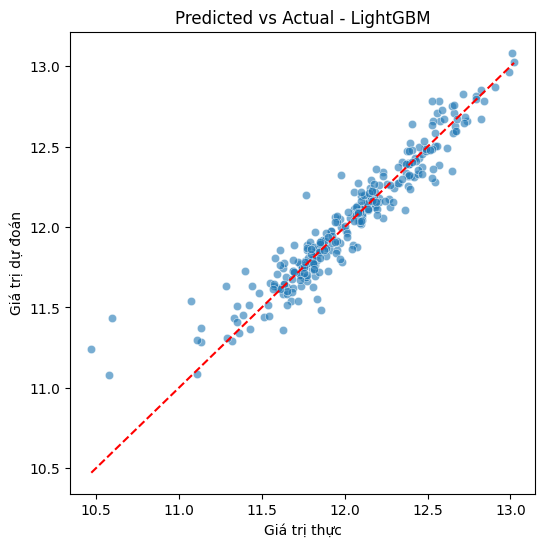

D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\evaluation\Evaluation.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


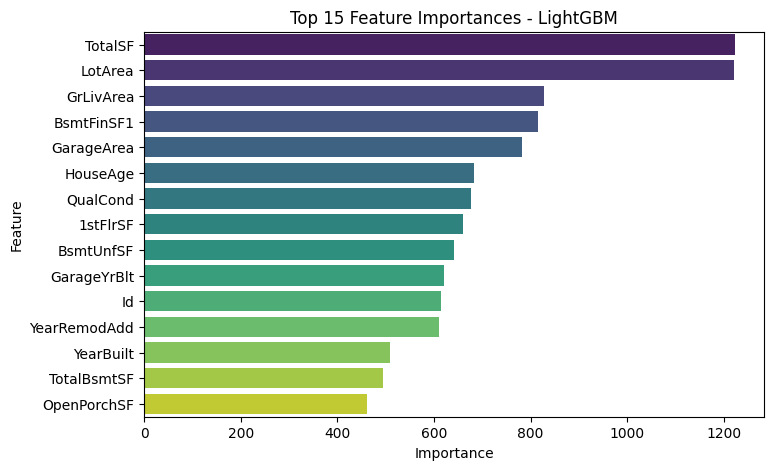

✅ Đã chạy đánh giá đầy đủ cho task: regression.
✅ Mô hình đã lưu local: experiments/models\LightGBM_regression_best_120118_20251028_120214_model.pkl


2025/10/28 12:02:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/28 12:02:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\LightGBM_regression_best_120118_20251028_120221_data.csv


In [ ]:
from pipeline.LightGBMPipline import LightGBMPipeline

pipeline = LightGBMPipeline(experiment_name="version2")
pipeline.run(
    df=train,
    target_col=target,
    task="regression",
    model_name="LightGBM",
    backend="mlflow"
)

Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 356, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 454, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1595, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1588, in _read


🚀 Start run: XGBoost_regression_best_120309
🔍 Đang tìm tham số tốt nhất cho XGBoost bằng Optuna (20 lần thử)...


Best trial: 0. Best value: -0.0162441:   5%|▌         | 1/20 [00:05<01:49,  5.76s/it]

[I 2025-10-28 12:03:15,697] Trial 0 finished with value: -0.016244133294286884 and parameters: {'n_estimators': 1389, 'learning_rate': 0.02483637741610103, 'max_depth': 12, 'subsample': 0.8557213911774939, 'colsample_bytree': 0.8725790218736456, 'reg_alpha': 1.0516121171730768e-05, 'reg_lambda': 5.22285096696009e-06, 'min_child_weight': 5, 'gamma': 1.2365607209689457e-06}. Best is trial 0 with value: -0.016244133294286884.


Best trial: 1. Best value: -0.0151538:  10%|█         | 2/20 [00:08<01:08,  3.80s/it]

...

[I 2025-10-28 12:03:46,209] Trial 17 finished with value: -0.014501287949957703 and parameters: {'n_estimators': 1234, 'learning_rate': 0.015013673000886865, 'max_depth': 9, 'subsample': 0.7160299027802584, 'colsample_bytree': 0.5556341733174, 'reg_alpha': 0.007943941877968352, 'reg_lambda': 0.0019284402737291576, 'min_child_weight': 9, 'gamma': 0.000382510979068634}. Best is trial 11 with value: -0.013872861958829688.


Best trial: 11. Best value: -0.0138729:  95%|█████████▌| 19/20 [00:37<00:01,  1.90s/it]

[I 2025-10-28 12:03:47,063] Trial 18 finished with value: -0.021129674064537047 and parameters: {'n_estimators': 1598, 'learning_rate': 0.1198652307166376, 'max_depth': 9, 'subsample': 0.679874895109433, 'colsample_bytree': 0.6418602147507667, 'reg_alpha': 2.5335181686483096e-07, 'reg_lambda': 7.325051648424325e-05, 'min_child_weight': 6, 'gamma': 0.9345491036960465}. Best is trial 11 with value: -0.013872861958829688.


Best trial: 11. Best value: -0.0138729: 100%|██████████| 20/20 [00:38<00:00,  1.95s/it]


[I 2025-10-28 12:03:48,885] Trial 19 finished with value: -0.015084584588269999 and parameters: {'n_estimators': 825, 'learning_rate': 0.019368798151223568, 'max_depth': 11, 'subsample': 0.8108896712859912, 'colsample_bytree': 0.7512250893032112, 'reg_alpha': 6.645567679032533e-06, 'reg_lambda': 0.005285309328931727, 'min_child_weight': 8, 'gamma': 0.0068589799735107905}. Best is trial 11 with value: -0.013872861958829688.
✅ Best params (Optuna): {'n_estimators': 1040, 'learning_rate': 0.010304585919359928, 'max_depth': 10, 'subsample': 0.5004910589440918, 'colsample_bytree': 0.6938565920488945, 'reg_alpha': 1.1470792406083519e-08, 'reg_lambda': 0.16760270273486844, 'min_child_weight': 7, 'gamma': 0.010916383838272484, 'enable_categorical': True, 'random_state': 42}
🚀 Huấn luyện mô hình XGBoost với 1166 mẫu...
[0]	validation_0-rmse:0.40747
[200]	validation_0-rmse:0.14415
[400]	validation_0-rmse:0.12280
[600]	validation_0-rmse:0.12053
[800]	validation_0-rmse:0.12041
[1000]	validation_0-

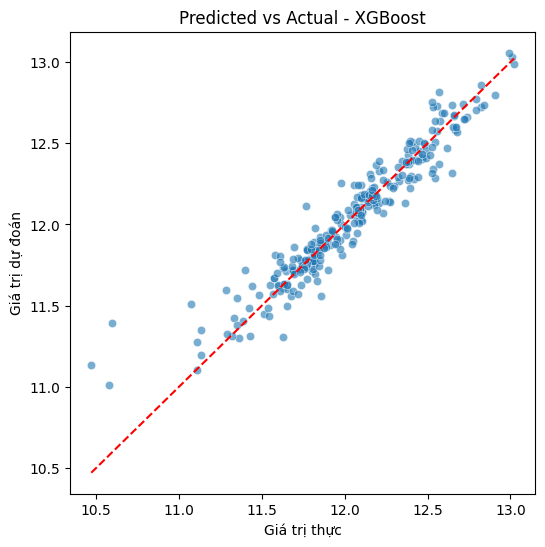

D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\evaluation\Evaluation.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


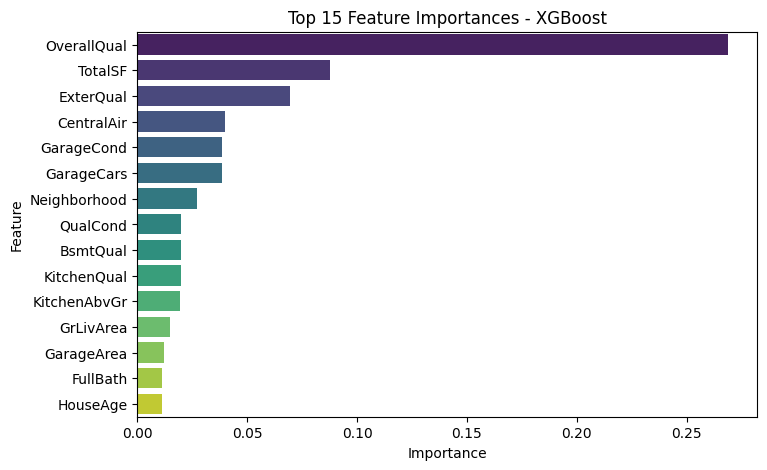

2025/10/28 12:03:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\XGBoost_regression_best_120309_20251028_120352_model.pkl


2025/10/28 12:03:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\XGBoost_regression_best_120309_20251028_120357_data.csv


In [ ]:
from pipeline.XGBoostPipeline import XGBoostPipeline
pipeline = XGBoostPipeline(experiment_name="version2")
pipeline.run(
    df=train,
    target_col=target,
    task="regression",
    model_name="XGBoost",
    backend="mlflow"
)

Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 356, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 454, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1595, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1588, in _read


🚀 Start run: CatBoost_regression_best_120426
🔍 Phát hiện 43 cột phân loại: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
🔍 Đang tìm tham số tốt nhất cho CatBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[W 2025-10-28 12:04:26,204] Trial 0 failed with parameters: {'depth': 6, 'learning_rate': 0.013672000500148447, 'iterations': 937, 'l2_leaf_reg': 0.00021551956203023025, 'subsample': 0.8398918709012343, 'colsample_bylevel': 0.9167628772843478} because of the following error: TypeError("catboost.core.CatBoostRegressor() got multiple values for keyword argument 'random_seed'").
Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\model\Catboost.py", line 105, in <lambda>
    study.optimize(lambda trial: self._objective_optuna(trial, X_train, y_train),
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\model\Catboost.py", line 65, in _objec

0:	learn: 0.3824120	test: 0.3973152	best: 0.3973152 (0)	total: 197ms	remaining: 3m 16s
100:	learn: 0.1059761	test: 0.1314878	best: 0.1314878 (100)	total: 3.29s	remaining: 29.3s
200:	learn: 0.0877158	test: 0.1215684	best: 0.1214804 (199)	total: 6.38s	remaining: 25.4s
300:	learn: 0.0763041	test: 0.1192180	best: 0.1192180 (300)	total: 9.32s	remaining: 21.6s
400:	learn: 0.0667010	test: 0.1182500	best: 0.1181774 (396)	total: 12.3s	remaining: 18.4s
500:	learn: 0.0590432	test: 0.1175455	best: 0.1173561 (455)	total: 15.3s	remaining: 15.3s
600:	learn: 0.0531300	test: 0.1171754	best: 0.1170193 (586)	total: 19.3s	remaining: 12.8s
700:	learn: 0.0474113	test: 0.1174068	best: 0.1170193 (586)	total: 23.2s	remaining: 9.9s
800:	learn: 0.0429740	test: 0.1172822	best: 0.1170193 (586)	total: 26.3s	remaining: 6.54s
900:	learn: 0.0387732	test: 0.1173873	best: 0.1170193 (586)	total: 29.8s	remaining: 3.27s
999:	learn: 0.0355213	test: 0.1175623	best: 0.1170193 (586)	total: 32.9s	remaining: 0us

bestTest = 0.11

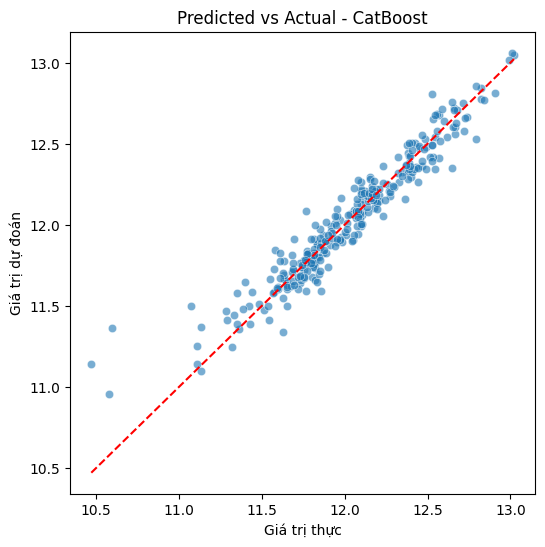

D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\evaluation\Evaluation.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


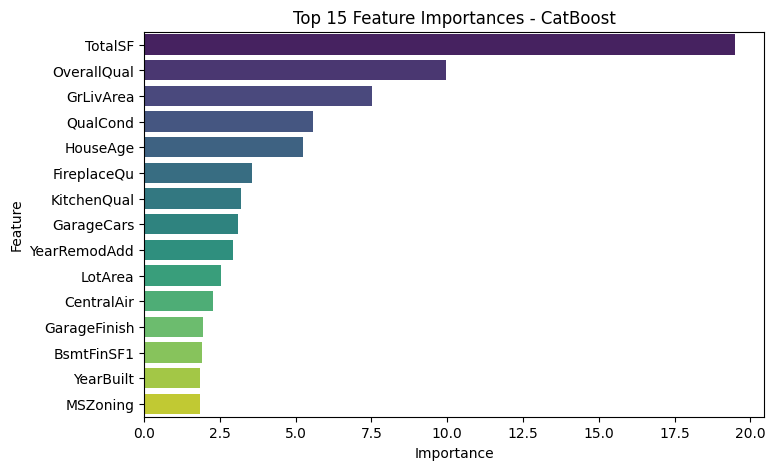

2025/10/28 12:04:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\CatBoost_regression_best_120426_20251028_120459_model.pkl


2025/10/28 12:05:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\CatBoost_regression_best_120426_20251028_120504_data.csv


In [ ]:
from pipeline.CatBoostPipeline import CatBoostPipeline
pipeline = CatBoostPipeline(experiment_name="version2")
pipeline.run(
    df=train,
    target_col=target,
    task="regression",
    model_name="CatBoost",
    backend="mlflow"
)

In [15]:
import joblib
model_da_load = joblib.load('experiments/models/XGBoost_regression_best_120309_20251028_120352_model.pkl')
Xgb_preds = model_da_load.predict(test)
y_log_preds = np.expm1(Xgb_preds)
submission= pd.DataFrame({'Id': test.Id,'SalePrice':y_log_preds })
submission.to_csv('submission.csv',index=False)

In [17]:
import joblib
cat = joblib.load('experiments/models/CatBoost_regression_best_120426_20251028_120459_model.pkl')
xgb = joblib.load('experiments/models/XGBoost_regression_best_120309_20251028_120352_model.pkl')
predict4 = cat.predict(test)
cat = np.expm1(predict4)
predict3 = xgb.predict(test)
XG = np.expm1(predict3)
predict_y = ( XG*0.45 + cat * 0.55)
submission= pd.DataFrame({'Id': test.Id,'SalePrice': predict_y})
submission.to_csv('submission.csv',index=False)